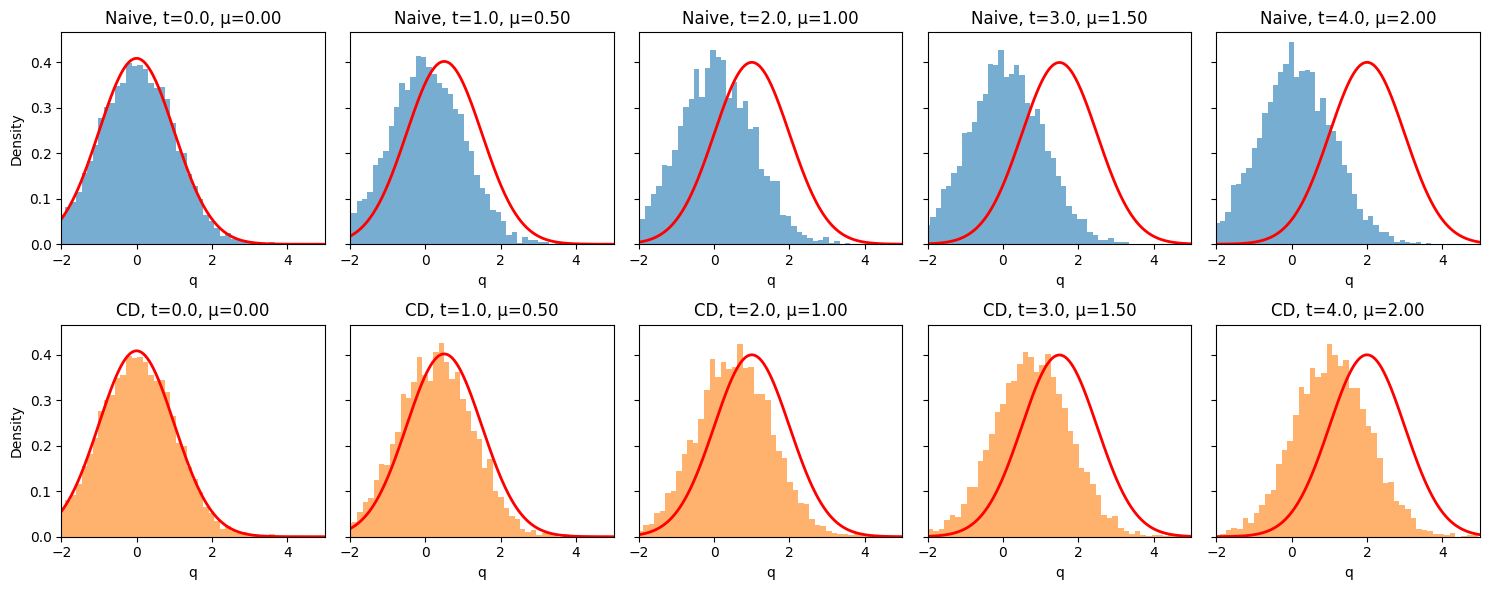

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
M = 5000          # number of particles
N_steps = 20      # number of time steps
delta_t = 0.2     # time step size for μ evolution
v = 0.5           # velocity of the Gaussian mean: μ(t) = v * t
epsilon = 0.1     # leapfrog step size
m = 1.0           # mass

# Pre-compute μ at each step
mu_vals = np.array([v * (k * delta_t) for k in range(N_steps+1)])

# Arrays to hold particle positions for naive and CD
q_naive = np.random.normal(loc=0.0, scale=1.0, size=M)
q_cd = q_naive.copy()

# Storage for snapshots
snapshots_naive = []
snapshots_cd = []

# Simulation over time steps
for k in range(N_steps+1):
    mu_k = mu_vals[k]
    # Record snapshots
    snapshots_naive.append(q_naive.copy())
    snapshots_cd.append(q_cd.copy())

    # Next target mean
    dot_mu = v  # constant velocity

    # Naive HMC-like update (single leapfrog step without MH)
    p_naive = np.random.normal(size=M) * np.sqrt(m)
    p_half = p_naive - 0.5 * epsilon * (q_naive - mu_k)
    q_naive = q_naive + epsilon * (p_half / m)
    # final half-step momentum (not used further)
    _ = p_half - 0.5 * epsilon * (q_naive - mu_k)

    # CD integrator update
    p_cd = np.random.normal(size=M) * np.sqrt(m)
    p_half_cd = p_cd - 0.5 * epsilon * (q_cd - mu_k)
    q_cd = q_cd + epsilon * (p_half_cd / m + dot_mu)
    _ = p_half_cd - 0.5 * epsilon * (q_cd - mu_k)

# Plot snapshots at selected timesteps
timesteps_to_plot = [0, 5, 10, 15, 20]

fig, axes = plt.subplots(2, len(timesteps_to_plot), figsize=(15, 6), sharey=True)
xs = np.linspace(-2, 5, 400)

for i, k in enumerate(timesteps_to_plot):
    mu_k = mu_vals[k]
    # Naive histogram
    ax_naive = axes[0, i]
    data_n = snapshots_naive[k]
    ax_naive.hist(data_n, bins=50, density=True, alpha=0.6, color='C0')
    rho = np.exp(-0.5 * (xs - mu_k)**2)
    rho /= np.trapz(rho, xs)
    ax_naive.plot(xs, rho, 'r-', lw=2)
    ax_naive.set_title(f"Naive, t={k*delta_t:.1f}, μ={mu_k:.2f}")
    if i == 0:
        ax_naive.set_ylabel("Density")

    # CD histogram
    ax_cd = axes[1, i]
    data_cd = snapshots_cd[k]
    ax_cd.hist(data_cd, bins=50, density=True, alpha=0.6, color='C1')
    rho = np.exp(-0.5 * (xs - mu_k)**2)
    rho /= np.trapz(rho, xs)
    ax_cd.plot(xs, rho, 'r-', lw=2)
    ax_cd.set_title(f"CD, t={k*delta_t:.1f}, μ={mu_k:.2f}")
    if i == 0:
        ax_cd.set_ylabel("Density")

    ax_naive.set_xlim(-2, 5)
    ax_naive.set_xlabel("q")
    ax_cd.set_xlim(-2, 5)
    ax_cd.set_xlabel("q")

plt.tight_layout()
plt.show()


[0.5 0.5 0.5 ... 0.  0.  0. ] dot_vals [0.   0.05 0.1  ... 1.   1.   1.  ] mu_vals


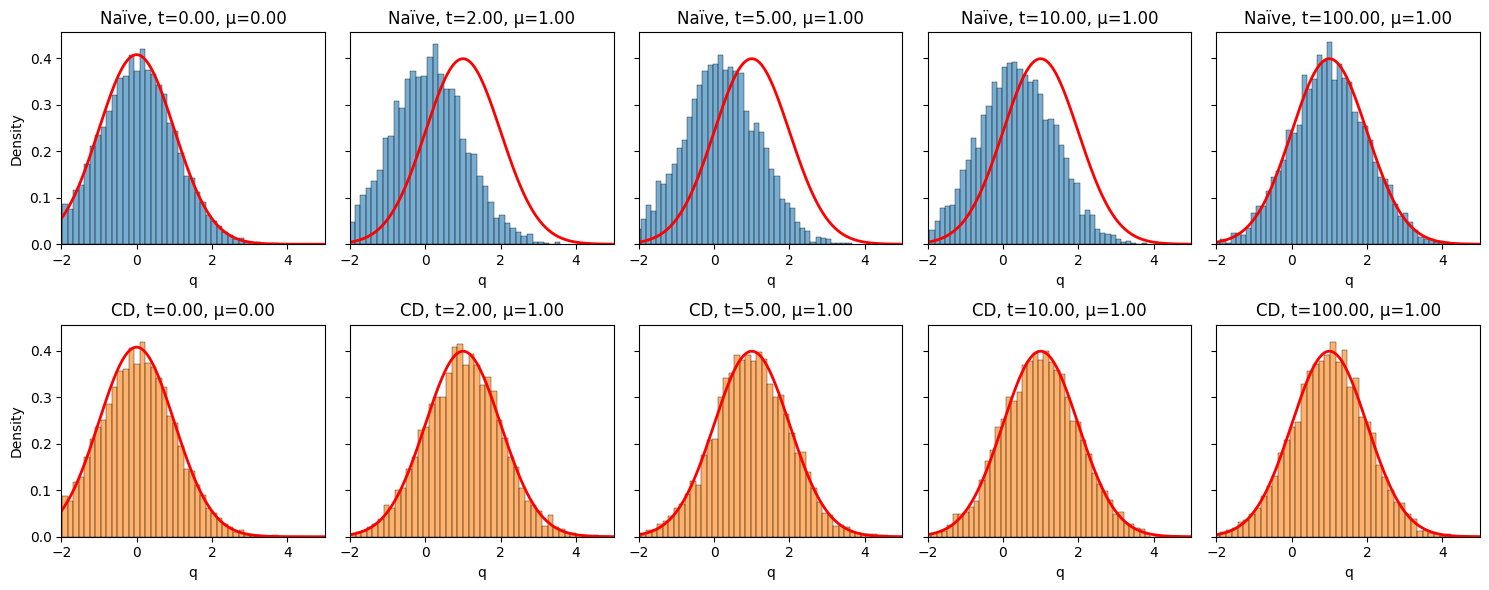

In [24]:
import jax
import jax.numpy as jnp
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# === 1. Simulation parameters ===
# M = 5000            # number of particles per ensemble
# N_steps = 100        # total number of discrete time steps
# delta_t = 0.1      # Δt between steps
# epsilon = 0.1       # leapfrog step size
# m = 1.0             # “mass” for HMC momentum scaling

M = 5000          # number of particles
N_steps = 1000      # number of time steps
delta_t = 0.1     # time step size for μ evolution
v = 0.5           # velocity of the Gaussian mean: μ(t) = v * t
epsilon = 0.1     # leapfrog step size
m = 1.0           # mass


# Define the piecewise motion for μ(t):
#    - For t < t_move:  μ(t) = v * t   (constant velocity)
#    - For t ≥ t_move:  μ(t) = v * t_move  (stops moving)
v = 0.5
t_move = 1.0  # after t_move, μ stops changing

# JAX PRNG key (for reproducible random numbers)
key = jax.random.PRNGKey(0)

# === 2. Define μ(t) and μ̇(t) via JAX’s autodiff ===
def mu_fn(t):
    # return v*t
    # piecewise: v*t if t < t_move, else v*t_move
    return jnp.where(t < 2.0, v * t, 1.0)

# Automatic derivative of mu_fn w.r.t. its argument:
dot_mu_fn = jax.grad(mu_fn)

# Precompute the discrete times and their μ and μ̇ values
times    = jnp.array([k * delta_t for k in range(N_steps + 1)])
mu_vals  = mu_fn(times)
dot_vals = jnp.array([dot_mu_fn(t) for t in times])

print(dot_vals, "dot_vals", mu_vals, "mu_vals")

# === 3. Initialize particle ensembles ===
# Both ensembles start from N(0,1) at t=0
key, subkey = jax.random.split(key)
q_naive = jax.random.normal(subkey, (M,))  # naïve particles
q_cd    = q_naive.copy()                   # CD particles (same initial)

# We’ll save snapshots (as NumPy arrays) for plotting
snapshots_naive = []
snapshots_cd    = []

# === 4. Time‐stepping loop ===
for k in range(N_steps + 1):
    mu_k      = mu_vals[k]
    dot_mu_k  = dot_vals[k]

    # Record current positions (convert to NumPy for plotting)
    snapshots_naive.append(np.array(q_naive))
    snapshots_cd.append(np.array(q_cd))

    if k == N_steps:
        break

    # 4a) --- Naïve “HMC‐like” single leapfrog step ---
    # Draw momenta p ~ N(0, m)
    key, subkey = jax.random.split(key)
    p_naive = jax.random.normal(subkey, (M,)) * jnp.sqrt(m)

    # Half‐step momentum under U(q) = ½*(q - μ_k)^2 ⇒ ∂U/∂q = (q - μ_k)
    p_half = p_naive - 0.5 * epsilon * (q_naive - mu_k)

    # Full‐step position update
    q_naive = q_naive + epsilon * (p_half / m)

    # Final half‐step momentum (not used further, since we skip MH)
    _ = p_half - 0.5 * epsilon * (q_naive - mu_k)
    # (In a full HMC you'd do Metropolis‐Hastings here.)

    # 4b) --- Counter-Diabatic leapfrog step ---
    # H_CD = p²/(2m) + ½*(q - μ_k)² + μ̇_k * p
    # ⇒ ȯq = p/m + μ̇_k,   ȯp = −(q - μ_k)
    key, subkey = jax.random.split(key)
    p_cd = jax.random.normal(subkey, (M,)) * jnp.sqrt(m)

    # Half‐step momentum under U
    p_half_cd = p_cd - 0.5 * epsilon * (q_cd - mu_k)

    # Full‐step position: add the CD drift term μ̇_k
    q_cd = q_cd + epsilon * (p_half_cd / m + dot_mu_k)

    # Final half‐step momentum under U again
    _ = p_half_cd - 0.5 * epsilon * (q_cd - mu_k)

# === 5. Plotting with Seaborn ===
# We will show snapshots at these step indices:
timesteps_to_plot = [0, 20, 50, 100, 1000]

fig, axes = plt.subplots(2, len(timesteps_to_plot), figsize=(15, 6), sharey=True)
xs = np.linspace(-2, 5, 400)

for i, k in enumerate(timesteps_to_plot):
    mu_k = float(mu_vals[k])

    # 5a) Naïve sampler histogram
    ax_naive = axes[0, i]
    data_n = snapshots_naive[k]
    sns.histplot(data_n, bins=50, stat='density', color='C0', alpha=0.6, ax=ax_naive)

    # Overlay the true Gaussian N(μ_k, 1)
    rho = np.exp(-0.5 * (xs - mu_k) ** 2)
    rho /= np.trapz(rho, xs)
    ax_naive.plot(xs, rho, 'r-', lw=2)

    ax_naive.set_title(f"Naïve, t={float(times[k]):.2f}, μ={mu_k:.2f}")
    if i == 0:
        ax_naive.set_ylabel("Density")

    # 5b) CD sampler histogram
    ax_cd = axes[1, i]
    data_cd = snapshots_cd[k]
    sns.histplot(data_cd, bins=50, stat='density', color='C1', alpha=0.6, ax=ax_cd)

    ax_cd.plot(xs, rho, 'r-', lw=2)
    ax_cd.set_title(f"CD, t={float(times[k]):.2f}, μ={mu_k:.2f}")
    if i == 0:
        ax_cd.set_ylabel("Density")

    ax_naive.set_xlim(-2, 5)
    ax_naive.set_xlabel("q")
    ax_cd.set_xlim(-2, 5)
    ax_cd.set_xlabel("q")

plt.tight_layout()
plt.show()


In [25]:
import jax
import jax.numpy as jnp
import optax
import numpy as np

# === 1. Problem setup: translating Gaussian where H0 = p²/(2m) + ½*(q - μ)² ===
m = 1.0

# We treat μ as the “parameter” λ.  Here, for simplicity, fix μ=0 during training.
mu = 0.0

# (a) Bare Hamiltonian and its λ‐derivative:
def H0(q, p, mu):
    return 0.5 * (p ** 2) / m + 0.5 * (q - mu) ** 2

# ∂_λ H0 = ∂H0/∂μ  (with μ playing the role of λ)
def dH0_dmu(q, p, mu):
    return -(q - mu)

# (b) We will parametrize A(q,p; θ) = θ₁·p + θ₂·(q·p).
#     Compute the Poisson bracket {A, H0} for that ansatz:
def poisson_bracket_A_H0(params, q, p, mu):
    theta1, theta2 = params  # θ₁, θ₂

    # A(q,p) = θ₁·p + θ₂·q·p
    # ⇒ ∂_q A = θ₂·p,   ∂_p A = θ₁ + θ₂·q
    dA_dq = theta2 * p
    dA_dp = theta1 + theta2 * q

    # In H0, ∂_p H0 = p/m,  ∂_q H0 = (q - μ)
    dH0_dp = p / m
    dH0_dq = (q - mu)

    # Poisson bracket = (∂_q A)(∂_p H0) - (∂_p A)(∂_q H0)
    return dA_dq * dH0_dp - dA_dp * dH0_dq

# Residual R = {A, H0} + ∂_λ H0  (we want R ≈ 0 everywhere)
def residual(params, q, p, mu):
    return poisson_bracket_A_H0(params, q, p, mu) + dH0_dmu(q, p, mu)

# === 2. Loss function: mean‐square residual under the instantaneous Gibbs measure ρ ∝ e^{-H0} ===
# We know for H0 = p²/2 + (q-μ)²/2, the equilibrium factorizes:
#   q ~ N(μ, 1),   p ~ N(0, m).
# Here we set m=1, so p ~ N(0,1).
def loss_fn(params, key, batch_size=1024):
    key_q, key_p = jax.random.split(key)
    # Sample q ~ N(μ,1), p ~ N(0,1)
    q_samples = mu + jax.random.normal(key_q, (batch_size,))
    p_samples = jax.random.normal(key_p, (batch_size,)) * jnp.sqrt(m)

    R = residual(params, q_samples, p_samples, mu)
    return jnp.mean(R ** 2)

# === 3. Optimizer setup (Optax Adam) ===
learning_rate = 0.1
optimizer = optax.adam(learning_rate)

# Initialize parameters θ₁, θ₂ = 0
params = jnp.array([0.0, 0.0])
opt_state = optimizer.init(params)

# JIT‐compile one update step
@jax.jit
def update(params, opt_state, key):
    loss, grads = jax.value_and_grad(loss_fn)(params, key)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

# === 4. Training loop ===
num_iters = 500
for i in range(num_iters):
    key = jax.random.PRNGKey(i)
    params, opt_state, loss = update(params, opt_state, key)
    if (i + 1) % 100 == 0:
        print(f"Iter {i+1:3d}: loss = {loss:.6f}, θ = {params}")

print("\nFinal learned parameters:")
print(f"  θ₁ (coeff of p)   = {params[0]:.6f}")
print(f"  θ₂ (coeff of q·p) = {params[1]:.6f}")


Iter 100: loss = 0.000009, θ = [-0.9969687  -0.00162083]
Iter 200: loss = 0.000000, θ = [-1.0000070e+00  1.0545178e-05]
Iter 300: loss = 0.000000, θ = [-1.000000e+00  7.474593e-08]
Iter 400: loss = 0.000000, θ = [-1.0000000e+00  1.1723666e-09]
Iter 500: loss = 0.000000, θ = [-1.0000000e+00  2.4096643e-11]

Final learned parameters:
  θ₁ (coeff of p)   = -1.000000
  θ₂ (coeff of q·p) = 0.000000


In [29]:
import jax
import jax.numpy as jnp
import optax
import numpy as np

# =============================================================================
# 1) FUNCTIONAL CONSTRUCTOR FOR H0
# =============================================================================

m = 1.0

def make_H0(mu):
    def H0_mu(q, p):
        return 0.5 * (p ** 2) / m + 0.5 * (q - mu) ** 2
    return H0_mu

# =============================================================================
# 2) FUNCTIONAL‐STYLE POISSON BRACKET
# =============================================================================

def poisson_bracket_fn(f, g):
    """
    Given two scalar‐valued functions f(q,p) and g(q,p),
    return a new function bracket(q,p) = {f,g}(q,p).
    """
    df_dq = jax.grad(lambda qr, pr: f(qr, pr), argnums=0)
    df_dp = jax.grad(lambda qr, pr: f(qr, pr), argnums=1)
    dg_dq = jax.grad(lambda qr, pr: g(qr, pr), argnums=0)
    dg_dp = jax.grad(lambda qr, pr: g(qr, pr), argnums=1)

    def bracket(q, p):
        a = df_dq(q, p)
        b = df_dp(q, p)
        c = dg_dq(q, p)
        d = dg_dp(q, p)
        return a * d - b * c

    return bracket

# =============================================================================
# 3) ∂_μ H0 AS A SCALAR FUNCTION
# =============================================================================

def make_dH0_dmu(mu):
    def dH0_dmu_scalar(q, p):
        return -(q - mu)
    return dH0_dmu_scalar

# =============================================================================
# 4) ANSATZ FOR A(q,p; θ)
# =============================================================================

def A_ansatz(params, q, p):
    θ1, θ2 = params
    return θ1 * p + θ2 * (q * p)

# =============================================================================
# 5) BUILD {A, H0} AND CORRECTED RESIDUAL R = {A,H0} - ∂_μ H0
# =============================================================================

def make_bracket_A_H0(mu):
    H0_mu = make_H0(mu)
    def bracket_A_H0(params, q, p):
        f = lambda qr, pr: A_ansatz(params, qr, pr)
        g = lambda qr, pr: H0_mu(qr, pr)
        bracket_fn = poisson_bracket_fn(f, g)
        return bracket_fn(q, p)
    return bracket_A_H0

def make_residual_fn(mu):
    bracket_A_H0 = make_bracket_A_H0(mu)
    dH0_mu = make_dH0_dmu(mu)
    def R(params, q, p):
        # Note the minus sign here:
        return bracket_A_H0(params, q, p) - dH0_mu(q, p)
    return R

# =============================================================================
# 6) LOSS OVER AN EMPIRICAL BATCH (use vmapped residual)
# =============================================================================

def make_loss_fn(mu):
    R_fn = make_residual_fn(mu)
    vmap_R = jax.vmap(lambda qr, pr, θ: R_fn(θ, qr, pr), in_axes=(0, 0, None))
    def loss_fn(params, qp_batch):
        qs = qp_batch[:, 0]
        ps = qp_batch[:, 1]
        R_vals = vmap_R(qs, ps, params)  # shape (batch_size,)
        return jnp.mean(R_vals ** 2)
    return loss_fn

# =============================================================================
# 7) OPTIMIZER SETUP & TRAINING LOOP
# =============================================================================

mu = 0.0
loss_fn = make_loss_fn(mu)

learning_rate = 0.1
optimizer = optax.adam(learning_rate)
params = jnp.array([0.0, 0.0])  # θ₁, θ₂
opt_state = optimizer.init(params)

@jax.jit
def update(params, opt_state, qp_batch):
    loss, grads = jax.value_and_grad(loss_fn)(params, qp_batch)
    updates, opt_state = optimizer.update(grads, opt_state)
    return optax.apply_updates(params, updates), opt_state, loss

rng = np.random.default_rng(42)
num_iters = 500
batch_size = 2048

for i in range(num_iters):
    q_samples = rng.standard_normal(batch_size) + mu
    p_samples = rng.standard_normal(batch_size) * np.sqrt(m)
    qp_batch = jnp.stack([q_samples, p_samples], axis=1)

    params, opt_state, loss = update(params, opt_state, qp_batch)
    if (i + 1) % 100 == 0:
        print(f"Iter {i+1:3d}: loss = {loss:.6f}, θ = {params}")

print("\nTrained parameters: θ₁ = {:.6f}, θ₂ = {:.6f}".format(params[0], params[1]))


Iter 100: loss = 0.000004, θ = [9.973779e-01 2.520858e-04]
Iter 200: loss = 0.000000, θ = [ 1.0000100e+00 -3.2631517e-06]
Iter 300: loss = 0.000000, θ = [ 1.0000000e+00 -1.9159986e-08]
Iter 400: loss = 0.000000, θ = [ 1.0000000e+00 -6.2355043e-10]
Iter 500: loss = 0.000000, θ = [ 1.000000e+00 -5.765397e-13]

Trained parameters: θ₁ = 1.000000, θ₂ = -0.000000


In [30]:
import jax
import jax.numpy as jnp
import optax

# =============================================================================
# 1) FUNCTIONAL‐STYLE POISSON BRACKET CONSTRUCTOR (scalar → scalar)
# =============================================================================
def poisson_bracket_fn(f, g):
    """
    Given two scalar‐output functions:
      f(q, p) -> scalar
      g(q, p) -> scalar
    returns a new function bracket(q, p) = {f, g}(q,p),
    computed by Automatic Differentiation:
      {f, g} = ∂_q f · ∂_p g  -  ∂_p f · ∂_q g.
    """
    # ∂_q f, ∂_p f
    df_dq = jax.grad(lambda qr, pr: f(qr, pr), argnums=0)
    df_dp = jax.grad(lambda qr, pr: f(qr, pr), argnums=1)
    # ∂_q g, ∂_p g
    dg_dq = jax.grad(lambda qr, pr: g(qr, pr), argnums=0)
    dg_dp = jax.grad(lambda qr, pr: g(qr, pr), argnums=1)

    def bracket(q, p):
        a = df_dq(q, p)   # ∂f/∂q
        b = df_dp(q, p)   # ∂f/∂p
        c = dg_dq(q, p)   # ∂g/∂q
        d = dg_dp(q, p)   # ∂g/∂p
        return a * d - b * c

    return bracket

# =============================================================================
# 2) MAIN FITTING FUNCTION
# =============================================================================
def fit_gauge_potential(
    H_fn,         # H_fn(q,p) -> scalar
    dH_dmu_fn,    # dH_dmu_fn(q,p) -> scalar
    A_ansatz_fn,  # A_ansatz_fn(params, q, p) -> scalar
    init_params,  # initial θ (1D array)
    samples,      # array of shape (N,2): rows = [q_i, p_i]
    num_iters=500,
    learning_rate=0.1
):
    """
    Fit a gauge potential A(q,p; θ) by minimizing
      mean_{(q,p)∈samples} [ {A, H}(q,p; θ) - ∂_μ H(q,p) ]^2.

    Args:
      H_fn:           function H_fn(q, p) -> scalar
      dH_dmu_fn:      function dH_dmu_fn(q, p) -> scalar
      A_ansatz_fn:    function A_ansatz_fn(params, q, p) -> scalar
      init_params:    1D array of initial θ
      samples:        numpy array (N,2), each row [q, p]
      num_iters:      number of optimization steps
      learning_rate:  optimizer learning rate

    Returns:
      A_fit:          function A_fit(q,p) -> scalar using learned θ
      params_learned: final θ array
    """
    # Convert samples to JAX
    qp_batch = jnp.array(samples)  # shape (N,2)

    # Build a scalar‐output Poisson bracket {A_ansatz, H}
    def bracket_A_H(params, q, p):
        f = lambda qr, pr: A_ansatz_fn(params, qr, pr)
        g = H_fn
        return poisson_bracket_fn(f, g)(q, p)

    # Residual R(q,p; θ) = {A,H} - ∂_μ H
    def residual(params, q, p):
        return bracket_A_H(params, q, p) - dH_dmu_fn(q, p)

    # Vectorize residual over the batch dimension
    vmap_R = jax.vmap(lambda qr, pr, θ: residual(θ, qr, pr), in_axes=(0, 0, None))

    # Define loss = mean(R^2)
    def loss_fn(params, qp_batch):
        qs = qp_batch[:, 0]
        ps = qp_batch[:, 1]
        R_vals = vmap_R(qs, ps, params)  # shape (N,)
        return jnp.mean(R_vals ** 2)

    # Set up optimizer (Adam)
    optimizer = optax.adam(learning_rate)
    params = jnp.array(init_params)
    opt_state = optimizer.init(params)

    @jax.jit
    def update(params, opt_state, qp_batch):
        loss, grads = jax.value_and_grad(loss_fn)(params, qp_batch)
        updates, opt_state = optimizer.update(grads, opt_state)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss

    # Training loop
    for _ in range(num_iters):
        params, opt_state, _ = update(params, opt_state, qp_batch)

    # Pack learned θ into a final callable A_fit(q,p)
    def A_fit(q, p):
        return A_ansatz_fn(params, q, p)

    return A_fit, params

# =============================================================================
# 3) USAGE EXAMPLE (Translating Gaussian at μ=0, m=1)
# =============================================================================

# Define H0(q,p; μ=0) and ∂_μ H0
m = 1.0
mu = 0.0

def H0_mu(q, p):
    return 0.5 * (p ** 2) / m + 0.5 * (q - mu) ** 2

def dH0_dmu(q, p):
    return -(q - mu)

# Parametric ansatz A(q,p; θ) = θ₁·p + θ₂·(q·p)
def A_ansatz_example(params, q, p):
    θ1, θ2 = params
    return θ1 * p + θ2 * (q * p)

# Initial guess for θ
init_params = jnp.array([0.0, 0.0])

# Generate synthetic samples from N(μ,1)×N(0,1)
import numpy as np
rng = np.random.default_rng(0)
batch_size = 2048
q_s = rng.standard_normal(batch_size) + mu
p_s = rng.standard_normal(batch_size) * np.sqrt(m)
samples = np.stack([q_s, p_s], axis=1)

# Fit
A_fitted, learned_params = fit_gauge_potential(
    H_fn=H0_mu,
    dH_dmu_fn=dH0_dmu,
    A_ansatz_fn=A_ansatz_example,
    init_params=init_params,
    samples=samples,
    num_iters=500,
    learning_rate=0.1
)

print("Learned θ:", learned_params)
# Expect θ₁ ≈ 1, θ₂ ≈ 0

# Test A_fitted on a point (q=1.0, p=2.0):
print("A_fitted(1.0, 2.0) =", A_fitted(1.0, 2.0))


Learned θ: [1.0000000e+00 2.6732035e-11]
A_fitted(1.0, 2.0) = 2.0


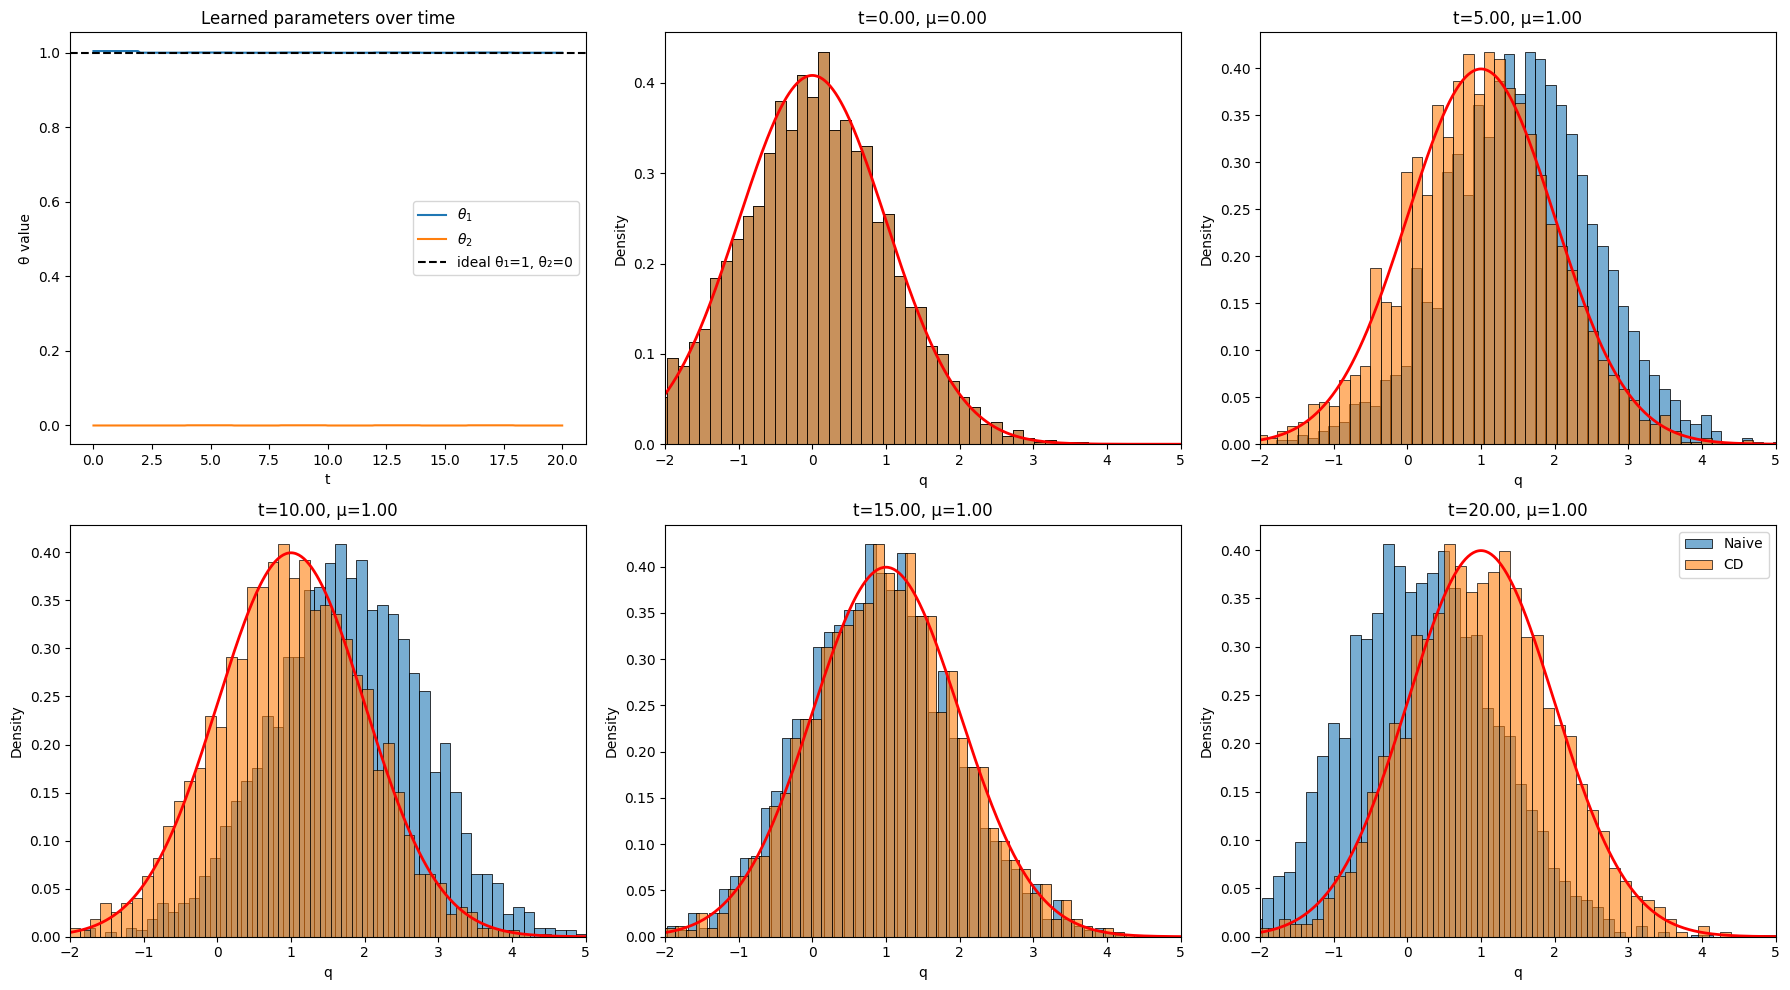

In [37]:
import jax
import jax.numpy as jnp
import optax
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =============================================================================
# 1) DEFINE HAMILTONIAN AND TARGET MOTION μ(t)
# =============================================================================
m = 1.0

def H0_mu(q, p, mu):
    return 0.5 * (p ** 2) / m + 0.5 * (q - mu) ** 2

def dH0_dmu(q, p, mu):
    return -(q - mu)

# Piecewise μ(t): constant velocity until t_move, then stops
v = 0.5
t_move = 1.0

# def mu_fn(t):
#     return jnp.where(t < t_move, v * t, v * t_move)

def mu_fn(t):
    # return v*t
    # piecewise: v*t if t < t_move, else v*t_move
    return jnp.where(t < 2.0, v * t, 1.0)

dot_mu_fn = jax.grad(mu_fn)

# =============================================================================
# 2) ANSATZ A(q,p; θ) AND PARTIALS
# =============================================================================
def A_ansatz(params, q, p):
    θ1, θ2 = params
    return θ1 * p + θ2 * (q * p)

def dA_dq(params, q, p):
    return jax.grad(lambda q: A_ansatz(params, q, p))(q)


# def dA_dq(params, q, p):
#     θ1, θ2 = params
#     return θ2 * p

def dA_dp(params, q, p):
    θ1, θ2 = params
    return θ1 + θ2 * q

# =============================================================================
# 3) POISSON BRACKET and RESIDUAL for FITTING
# =============================================================================
def poisson_bracket_A_H(params, q, p, mu):
    # ∂A/∂q * ∂H0/∂p - ∂A/∂p * ∂H0/∂q
    return dA_dq(params, q, p) * (p / m) - dA_dp(params, q, p) * (q - mu)

def residual(params, q, p, mu):
    return poisson_bracket_A_H(params, q, p, mu) - dH0_dmu(q, p, mu)

# =============================================================================
# 4) FIT FUNCTION USING JAX + OPTAX
# =============================================================================
def fit_gauge_potential(mu, samples, init_params, num_iters=200, lr=0.05):
    """
    Fit A(q,p; θ) by minimizing mean_{samples}[ ( {A,H} - ∂H/∂μ )^2 ].
    """
    qp_batch = jnp.array(samples)  # shape (N,2)
    params = jnp.array(init_params)

    def R(params, q, p):
        return residual(params, q, p, mu)

    vmap_R = jax.vmap(lambda qr, pr, θ: R(θ, qr, pr), in_axes=(0, 0, None))

    def loss_fn(params, qp_batch):
        qs = qp_batch[:, 0]
        ps = qp_batch[:, 1]
        R_vals = vmap_R(qs, ps, params)
        return jnp.mean(R_vals ** 2)

    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)

    @jax.jit
    def update(params, opt_state, qp_batch):
        loss, grads = jax.value_and_grad(loss_fn)(params, qp_batch)
        updates, opt_state = optimizer.update(grads, opt_state)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss

    for _ in range(num_iters):
        params, opt_state, _ = update(params, opt_state, qp_batch)

    return params

# =============================================================================
# 5) CD LEAPFROG USING PARAMETRIC A
# =============================================================================
def cd_leapfrog_step(params, q, p, mu, dot_mu, eps):
    # half-kick on p: p -= 0.5*eps*(∂U/∂q + dot_mu*∂A/∂q)
    grad_U = (q - mu)
    p = p - 0.5 * eps * (grad_U + dot_mu * dA_dq(params, q, p))
    # drift on q: q += eps*(p/m + dot_mu*∂A/∂p)
    q = q + eps * (p / m + dot_mu * dA_dp(params, q, p))
    # returns intermediate (q, p); caller applies second half-kick
    return q, p

# =============================================================================
# 6) SIMULATION: NAÏVE HMC VS CD WITH ONLINE FITTING
# =============================================================================
# Simulation parameters
M = 3000
N_steps = 200
delta_t = 0.1
eps = 0.1

# Initialize particles
key = jax.random.PRNGKey(0)
key, sub = jax.random.split(key)
q_naive = jax.random.normal(sub, (M,))
key, sub = jax.random.split(key)
p_naive = jax.random.normal(sub, (M,)) * jnp.sqrt(m)


q_cd = q_naive.copy()
p_cd = p_naive.copy()

# Initial θ
theta = jnp.array([0.0, 0.0])

# Storage
theta_history = []
snapshots = {'naive': [], 'cd': [], 'mu': []}

for k in range(N_steps + 1):
    t_k = k * delta_t
    mu_k = float(mu_fn(t_k))
    dot_mu_k = float(dot_mu_fn(t_k))

    # Record histograms every 50 steps
    if k % 50 == 0:
        snapshots['naive'].append(np.array(q_naive))
        snapshots['cd'].append(np.array(q_cd))
        snapshots['mu'].append(mu_k)

    # Fit new A every 20 steps
    if k % 20 == 0 and k < N_steps:
        samples = np.stack([np.array(q_cd), np.array(p_cd)], axis=1)
        theta = fit_gauge_potential(mu_k, samples, init_params=theta, num_iters=100, lr=0.05)

    theta_history.append(np.array(theta))

    if k == N_steps:
        break

    # --- Naïve HMC step ---
    p_naive = p_naive - 0.5 * eps * (q_naive - mu_k)
    q_naive = q_naive + eps * (p_naive / m)
    mu_k1 = float(mu_fn(t_k + delta_t))
    p_naive = p_naive - 0.5 * eps * (q_naive - mu_k1)

    # --- CD step using learned θ ---
    p_cd = p_cd - 0.5 * eps * ((q_cd - mu_k) + dot_mu_k * dA_dq(theta, q_cd, p_cd))
    q_cd = q_cd + eps * (p_cd / m + dot_mu_k * dA_dp(theta, q_cd, p_cd))
    dot_mu_k1 = float(dot_mu_fn(t_k + delta_t))
    p_cd = p_cd - 0.5 * eps * ((q_cd - mu_k1) + dot_mu_k1 * dA_dq(theta, q_cd, p_cd))

# Convert θ history to NumPy
theta_history = np.stack(theta_history, axis=0)

# =============================================================================
# 7) PLOTTING
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot θ₁ and θ₂ over time
times = np.arange(N_steps + 1) * delta_t
axes[0, 0].plot(times, theta_history[:, 0], label=r'$\theta_1$')
axes[0, 0].plot(times, theta_history[:, 1], label=r'$\theta_2$')
axes[0, 0].axhline(1.0, color='k', linestyle='--', label='ideal θ₁=1, θ₂=0')
axes[0, 0].set_title("Learned parameters over time")
axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("θ value")
axes[0, 0].legend()

# Plot histogram snapshots for naive vs CD
for idx in range(len(snapshots['naive'])):
    ax = axes.flatten()[idx + 1]
    naive_snap = snapshots['naive'][idx]
    cd_snap = snapshots['cd'][idx]
    mu_val = snapshots['mu'][idx]

    sns.histplot(naive_snap, bins=50, stat='density', color='C0', alpha=0.6, ax=ax, label="Naive")
    sns.histplot(cd_snap, bins=50, stat='density', color='C1', alpha=0.6, ax=ax, label="CD")
    xs = np.linspace(-2, 5, 400)
    rho = np.exp(-0.5 * (xs - mu_val) ** 2)
    rho /= np.trapz(rho, xs)
    ax.plot(xs, rho, 'r-', lw=2)
    ax.set_title(f"t={idx*50*delta_t:.2f}, μ={mu_val:.2f}")
    ax.set_xlabel("q")
    ax.set_ylabel("Density")
    ax.set_xlim(-2, 5)

plt.tight_layout()
plt.legend()
plt.show()


